In [1]:
import sys
import torch

print("Python:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("\nGPU:")
    print(torch.cuda.get_device_name(0))

    print("\nCUDA used by PyTorch:")
    print(torch.version.cuda)

    print("\nVRAM:")
    print(round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        2
    ), "GB")

Python:
C:\Users\Computer House\anaconda3\envs\swin-assignment\python.exe

PyTorch:
2.14.0+cu132

CUDA available:
True

GPU:
NVIDIA GeForce RTX 3070 Ti Laptop GPU

CUDA used by PyTorch:
13.2

VRAM:
8.0 GB


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
    print("Reserved:", torch.cuda.memory_reserved() / 1024**2, "MB")

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Allocated: 0.0 MB
Reserved: 0.0 MB


In [5]:
x = torch.randn(2000, 2000, device=device)
y = torch.randn(2000, 2000, device=device)

z = x @ y

print("Matrix multiplication successful!")
print("Result device:", z.device)

del x, y, z
torch.cuda.empty_cache()

Matrix multiplication successful!
Result device: cuda:0


In [1]:
import sys
import torch
import timm

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("timm:", timm.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: C:\Users\Computer House\anaconda3\envs\swin-assignment\python.exe
PyTorch: 2.14.0+cu132
CUDA: True
timm: 1.0.29
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [2]:
import torch
import timm

device = torch.device("cuda")

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

print("Model loaded successfully!")
print("Device:", next(model.parameters()).device)

C:\Users\Computer House\anaconda3\envs\swin-assignment\lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Computer House\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\Computer House\anaconda3\envs\swin-assignment\lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Computer House\.cache\huggingface\hub\models--timm--swin_tiny_patch4_window7_224.ms_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model loaded successfully!
Device: cuda:0


In [3]:
import torch
import timm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load Swin-T
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nModel loaded successfully!")
print("Model device:", next(model.parameters()).device)

PyTorch: 2.14.0+cu132
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU

Model loaded successfully!
Model device: cuda:0


In [4]:
import torch
import timm

# Use GPU
device = torch.device("cuda")

# Create Swin-T baseline model
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)

model = model.to(device)
model.train()

# Test batch size required by assignment
batch_size = 32

# Fake images: 32 images, 3 channels, 224x224
x = torch.randn(
    batch_size, 3, 224, 224,
    device=device
)

# Fake labels for 10 EuroSAT classes
y = torch.randint(
    0, 10,
    (batch_size,),
    device=device
)

# Clear GPU cache
torch.cuda.empty_cache()

# Forward pass
outputs = model(x)

print("Forward pass successful!")
print("Input shape:", x.shape)
print("Output shape:", outputs.shape)

# Loss
criterion = torch.nn.CrossEntropyLoss()
loss = criterion(outputs, y)

# Backward pass
loss.backward()

print("Backward pass successful!")
print("Loss:", loss.item())

# GPU memory information
allocated = torch.cuda.memory_allocated() / 1024**3
reserved = torch.cuda.memory_reserved() / 1024**3

print(f"GPU memory allocated: {allocated:.2f} GB")
print(f"GPU memory reserved:  {reserved:.2f} GB")
print("GPU test completed successfully!")

Forward pass successful!
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])
Backward pass successful!
Loss: 2.3146417140960693
GPU memory allocated: 0.24 GB
GPU memory reserved:  3.80 GB
GPU test completed successfully!


In [5]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import train_test_split
import os

# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
BATCH_SIZE = 32
IMAGE_SIZE = 224

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# 2. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# 3. DOWNLOAD EURO-SAT
# ============================================================

data_dir = "./data"

print("Downloading/loading EuroSAT...")

dataset_for_split = datasets.EuroSAT(
    root=data_dir,
    download=True,
    transform=None
)

print("Dataset loaded!")
print("Total images:", len(dataset_for_split))
print("Number of classes:", len(dataset_for_split.classes))
print("Classes:")
print(dataset_for_split.classes)

Downloading/loading EuroSAT...


100%|██████████| 94.3M/94.3M [00:21<00:00, 4.42MB/s]


Dataset loaded!
Total images: 27000
Number of classes: 10
Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
# ============================================================
# 4. CREATE FIXED STRATIFIED 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np
import os

SEED = 42

# Get labels for every image
labels = np.array(dataset_for_split.targets)

# Create indices
all_indices = np.arange(len(dataset_for_split))

# 80% train / 20% validation
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print("Split created successfully!")
print("Total samples:", len(all_indices))
print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

# Check percentages
print(f"\nTraining percentage: {len(train_indices)/len(all_indices)*100:.2f}%")
print(f"Validation percentage: {len(val_indices)/len(all_indices)*100:.2f}%")

# ============================================================
# 5. CHECK CLASS DISTRIBUTION
# ============================================================

print("\nClass distribution:")
print("-" * 60)

for class_id, class_name in enumerate(dataset_for_split.classes):

    total_count = np.sum(labels == class_id)
    train_count = np.sum(labels[train_indices] == class_id)
    val_count = np.sum(labels[val_indices] == class_id)

    print(
        f"{class_name:25s} | "
        f"Total: {total_count:4d} | "
        f"Train: {train_count:4d} | "
        f"Val: {val_count:4d}"
    )

# ============================================================
# 6. SAVE SPLIT INDICES
# ============================================================

os.makedirs("./splits", exist_ok=True)

np.save("./splits/train_indices.npy", train_indices)
np.save("./splits/val_indices.npy", val_indices)

print("\nSplit indices saved!")
print("./splits/train_indices.npy")
print("./splits/val_indices.npy")

Split created successfully!
Total samples: 27000
Training samples: 21600
Validation samples: 5400

Training percentage: 80.00%
Validation percentage: 20.00%

Class distribution:
------------------------------------------------------------
AnnualCrop                | Total: 3000 | Train: 2400 | Val:  600
Forest                    | Total: 3000 | Train: 2400 | Val:  600
HerbaceousVegetation      | Total: 3000 | Train: 2400 | Val:  600
Highway                   | Total: 2500 | Train: 2000 | Val:  500
Industrial                | Total: 2500 | Train: 2000 | Val:  500
Pasture                   | Total: 2000 | Train: 1600 | Val:  400
PermanentCrop             | Total: 2500 | Train: 2000 | Val:  500
Residential               | Total: 3000 | Train: 2400 | Val:  600
River                     | Total: 2500 | Train: 2000 | Val:  500
SeaLake                   | Total: 3000 | Train: 2400 | Val:  600

Split indices saved!
./splits/train_indices.npy
./splits/val_indices.npy


In [7]:
# ============================================================
# 6. CREATE TRAINING AND VALIDATION DATASETS
# ============================================================

from torch.utils.data import DataLoader, Subset

# ------------------------------------------------------------
# Training dataset
# ------------------------------------------------------------

train_dataset_full = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=train_transform
)

# ------------------------------------------------------------
# Validation dataset
# ------------------------------------------------------------

val_dataset_full = datasets.EuroSAT(
    root="./data",
    download=False,
    transform=val_transform
)

# Use the SAME indices we created earlier
train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    val_dataset_full,
    val_indices
)

# ============================================================
# 7. CREATE DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ============================================================
# 8. CHECK
# ============================================================

print("DataLoaders created successfully!")
print()
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Batch size:", 32)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

DataLoaders created successfully!

Training images: 21600
Validation images: 5400
Batch size: 32
Training batches: 675
Validation batches: 169


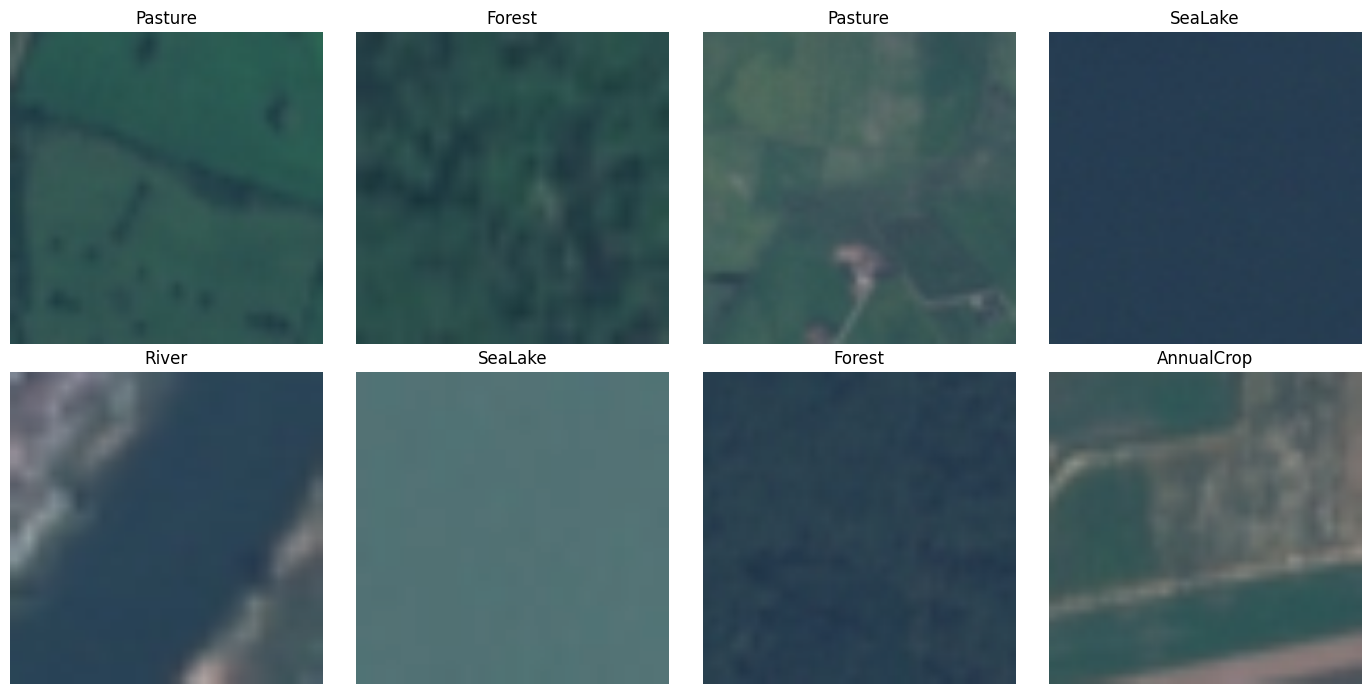

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels_batch = next(iter(train_loader))

# Display 8 images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# ImageNet normalization values
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flat):

    # Convert from [C, H, W] -> [H, W, C]
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization so we can display the image correctly
    image = image * std + mean

    # Keep values valid for displaying
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    # Get class name
    class_name = dataset_for_split.classes[labels_batch[i].item()]

    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

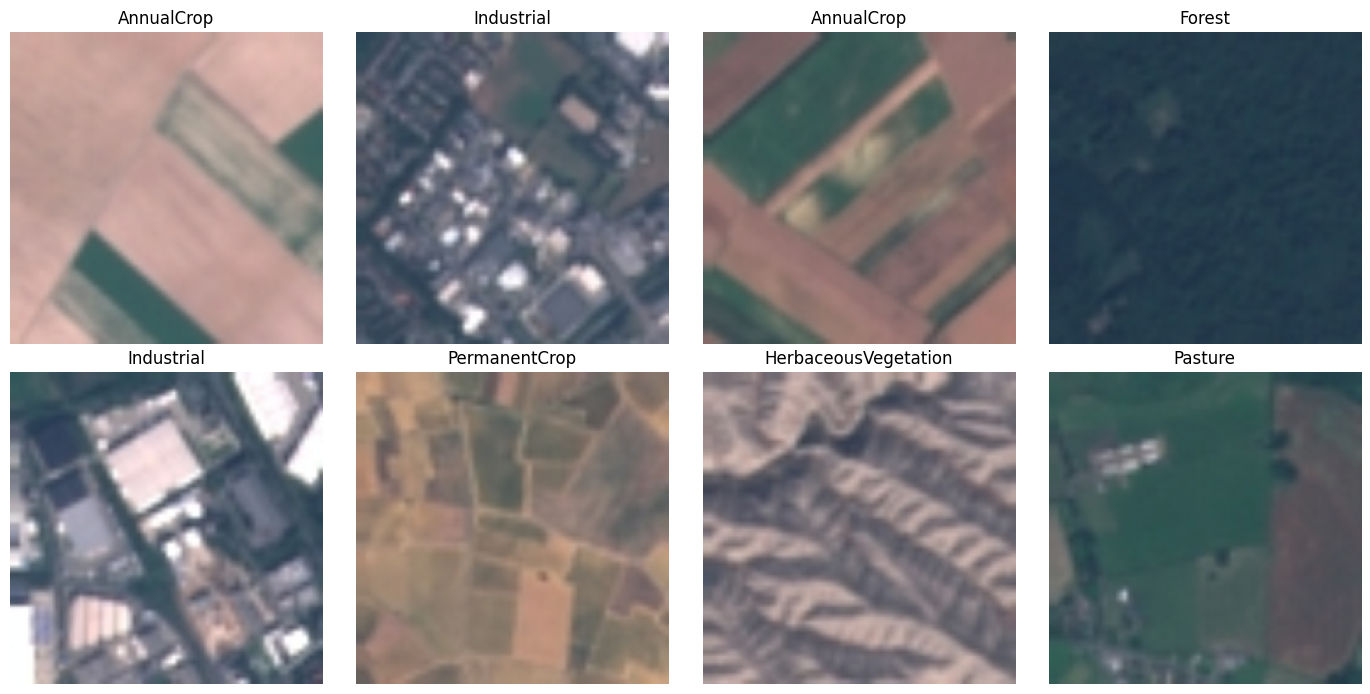

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get one validation batch
val_images, val_labels = next(iter(val_loader))

# Show 8 validation images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flat):

    image = val_images[i].permute(1, 2, 0).numpy()

    # Undo normalization
    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    class_name = dataset_for_split.classes[val_labels[i].item()]
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# BASELINE SWIN-T TRAINING
# Advanced Computer Vision Assignment
# ============================================================

import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# For reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 2. CONFIGURATION
# ============================================================

NUM_CLASSES = 10
EPOCHS = 30
BATCH_SIZE = 32

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0

OUTPUT_DIR = "./outputs/baseline_swin_t"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("BASELINE SWIN-T EXPERIMENT")
print("=" * 70)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup epochs:", WARMUP_EPOCHS)
print("Gradient clipping:", GRAD_CLIP)

# ============================================================
# 3. CREATE PRETRAINED SWIN-T
# ============================================================

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print("\nModel:")
print("Swin-Tiny Patch4 Window7 224")
print("Number of classes:", NUM_CLASSES)

# ============================================================
# 4. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# 5. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ============================================================
# 6. LEARNING-RATE SCHEDULER
#
# 5-epoch linear warmup followed by cosine decay.
# ============================================================

def get_learning_rate(epoch):
    """
    Returns learning rate for the current epoch.

    Epoch numbering starts at 1.
    """

    # -------------------------
    # Warmup
    # -------------------------
    if epoch <= WARMUP_EPOCHS:

        # Start at 20% of target LR
        # and linearly increase to target LR.
        warmup_start = LEARNING_RATE * 0.2

        alpha = epoch / WARMUP_EPOCHS

        lr = warmup_start + alpha * (
            LEARNING_RATE - warmup_start
        )

    # -------------------------
    # Cosine decay
    # -------------------------
    else:

        progress = (
            (epoch - WARMUP_EPOCHS)
            / (EPOCHS - WARMUP_EPOCHS)
        )

        lr = LEARNING_RATE * 0.5 * (
            1 + np.cos(np.pi * progress)
        )

    return lr


def set_learning_rate(optimizer, lr):

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr


# ============================================================
# 7. TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    grad_clip
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Gradient statistics
    grad_norms_before_clip = []
    global_grad_norms = []
    max_grad_norms = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backward
        loss.backward()

        # ----------------------------------------------------
        # Calculate gradient norms BEFORE clipping
        # ----------------------------------------------------

        parameter_grad_norms = []

        for parameter in model.parameters():

            if parameter.grad is not None:

                norm = parameter.grad.detach().norm(2).item()

                parameter_grad_norms.append(norm)

        if parameter_grad_norms:

            parameter_grad_norms = np.array(
                parameter_grad_norms
            )

            avg_grad = parameter_grad_norms.mean()

            max_grad = parameter_grad_norms.max()

            global_grad = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=grad_clip
            )

            global_grad = float(global_grad)

            grad_norms_before_clip.append(avg_grad)
            global_grad_norms.append(global_grad)
            max_grad_norms.append(max_grad)

        else:

            grad_norms_before_clip.append(0.0)
            global_grad_norms.append(0.0)
            max_grad_norms.append(0.0)

        # ----------------------------------------------------
        # Optimizer update
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    avg_grad_norm = float(
        np.mean(grad_norms_before_clip)
    )

    avg_global_grad_norm = float(
        np.mean(global_grad_norms)
    )

    avg_max_grad_norm = float(
        np.mean(max_grad_norms)
    )

    maximum_global_grad_norm = float(
        np.max(global_grad_norms)
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "avg_grad_norm": avg_grad_norm,
        "avg_global_grad_norm": avg_global_grad_norm,
        "avg_max_grad_norm": avg_max_grad_norm,
        "max_global_grad_norm": maximum_global_grad_norm
    }


# ============================================================
# 8. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    loss = running_loss / total

    accuracy = 100.0 * correct / total

    return loss, accuracy


# ============================================================
# 9. SAVE EXPERIMENT CONFIGURATION
# ============================================================

config = {
    "experiment": "baseline_swin_t",
    "dataset": "EuroSAT RGB",
    "num_classes": NUM_CLASSES,
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "split": "80/20 stratified",
    "split_seed": 42,
    "model_seed": SEED,
    "model": "swin_tiny_patch4_window7_224",
    "pretrained": True,
    "image_size": 224,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS,
    "scheduler": "5-epoch warmup + cosine decay",
    "gradient_clipping": GRAD_CLIP
}

with open(
    os.path.join(OUTPUT_DIR, "config.json"),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("\nConfiguration saved.")


# ============================================================
# 10. TRAINING LOOP
# ============================================================

history = []

best_val_accuracy = -1.0
best_epoch = -1

print("\n" + "=" * 70)
print("STARTING TRAINING")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    start_time = time.time()

    # Set LR
    current_lr = get_learning_rate(epoch)

    set_learning_rate(
        optimizer,
        current_lr
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_results = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        grad_clip=GRAD_CLIP
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    epoch_time = time.time() - start_time

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    row = {
        "epoch": epoch,
        "learning_rate": current_lr,

        "train_loss": train_results["loss"],
        "train_accuracy": train_results["accuracy"],

        "val_loss": val_loss,
        "val_accuracy": val_accuracy,

        "avg_grad_norm": train_results["avg_grad_norm"],
        "avg_global_grad_norm": train_results["avg_global_grad_norm"],
        "avg_max_grad_norm": train_results["avg_max_grad_norm"],
        "max_global_grad_norm": train_results["max_global_grad_norm"],

        "epoch_time_seconds": epoch_time
    }

    history.append(row)

    # --------------------------------------------------------
    # Save CSV after EVERY epoch
    # --------------------------------------------------------

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "history.csv"
        ),
        index=False
    )

    # --------------------------------------------------------
    # Save latest checkpoint
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_accuracy,
            "history": history
        },
        os.path.join(
            OUTPUT_DIR,
            "latest_checkpoint.pth"
        )
    )

    # --------------------------------------------------------
    # Save BEST checkpoint
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
                "history": history
            },
            os.path.join(
                OUTPUT_DIR,
                "best_model.pth"
            )
        )

        best_marker = " <-- BEST"

    else:

        best_marker = ""

    # --------------------------------------------------------
    # Print epoch
    # --------------------------------------------------------

    print(
        f"\nEpoch {epoch:02d}/{EPOCHS} | "
        f"LR={current_lr:.8f}"
    )

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
        f"{best_marker}"
    )

    print(
        f"Avg Grad Norm: "
        f"{train_results['avg_grad_norm']:.4f}"
    )

    print(
        f"Global Grad Norm: "
        f"{train_results['avg_global_grad_norm']:.4f}"
    )

    print(
        f"Max Grad Norm: "
        f"{train_results['avg_max_grad_norm']:.4f}"
    )

    print(
        f"Epoch Time: "
        f"{epoch_time / 60:.2f} min"
    )

# ============================================================
# 11. FINAL SUMMARY
# ============================================================

history_df = pd.DataFrame(history)

print("\n" + "=" * 70)
print("BASELINE TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best Epoch: "
    f"{best_epoch}"
)

print(
    f"History saved to: "
    f"{OUTPUT_DIR}/history.csv"
)

print(
    f"Best model saved to: "
    f"{OUTPUT_DIR}/best_model.pth"
)


BASELINE SWIN-T EXPERIMENT
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Epochs: 30
Batch size: 32
Learning rate: 5e-05
Weight decay: 0.0001
Warmup epochs: 5
Gradient clipping: 1.0

Model:
Swin-Tiny Patch4 Window7 224
Number of classes: 10

Configuration saved.

STARTING TRAINING

Epoch 01/30 | LR=0.00001800
Train Loss: 0.4057 | Train Acc: 87.96%
Val Loss: 0.1240 | Val Acc: 95.44% <-- BEST
Avg Grad Norm: 0.6898
Global Grad Norm: 22.7302
Max Grad Norm: 18.3379
Epoch Time: 23.92 min

Epoch 02/30 | LR=0.00002600
Train Loss: 0.2058 | Train Acc: 93.68%
Val Loss: 0.1166 | Val Acc: 96.00% <-- BEST
Avg Grad Norm: 0.5405
Global Grad Norm: 16.7891
Max Grad Norm: 13.1624
Epoch Time: 20.33 min

Epoch 03/30 | LR=0.00003400
Train Loss: 0.1934 | Train Acc: 94.02%
Val Loss: 0.0822 | Val Acc: 97.22% <-- BEST
Avg Grad Norm: 0.4666
Global Grad Norm: 14.7405
Max Grad Norm: 11.6518
Epoch Time: 15.03 min

Epoch 04/30 | LR=0.00004200
Train Loss: 0.1697 | Train Acc: 94.93%
Val Loss: 0.0788 | Val Acc

BASELINE HISTORY LOADED
Number of epochs: 30
History file: ./outputs/baseline_swin_t\history.csv

BASELINE SUMMARY
----------------------------------------------------------------------
Best Epoch:              26
Best Validation Acc:     99.00%
Best Validation Loss:    0.0505


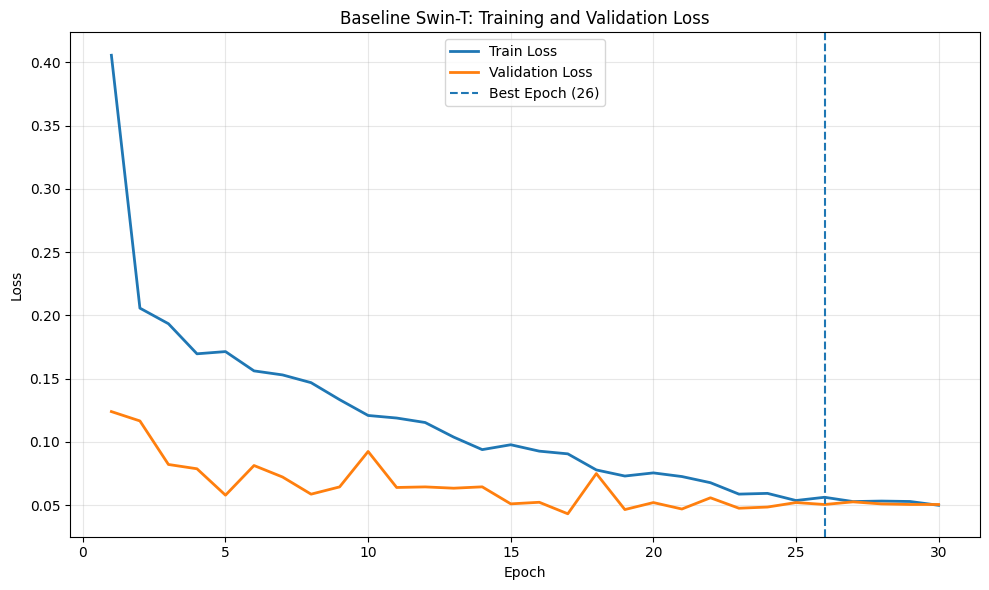

✓ Saved: ./outputs/baseline_swin_t\plots\baseline_loss_curve.png


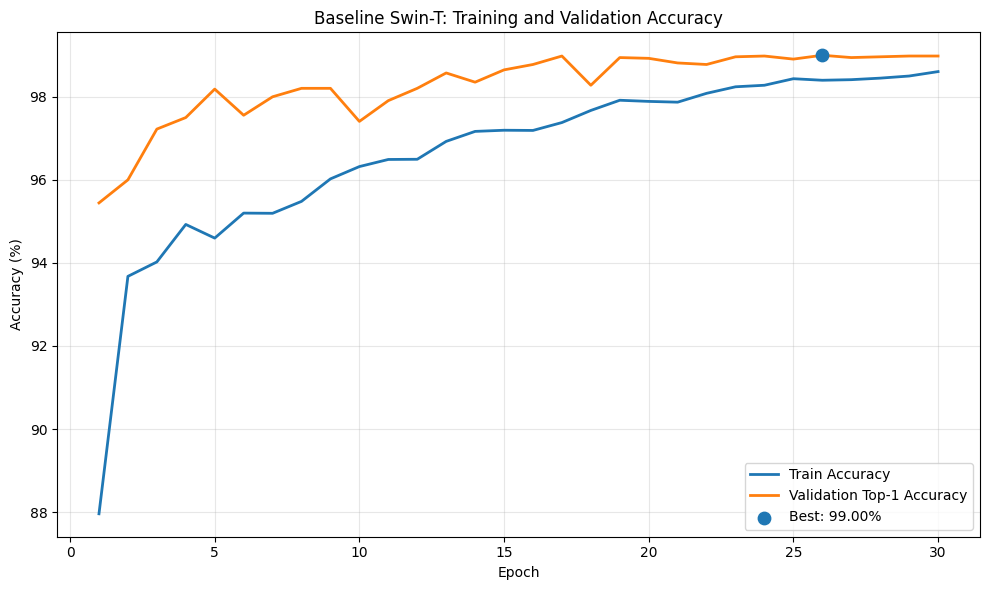

✓ Saved: ./outputs/baseline_swin_t\plots\baseline_accuracy_curve.png


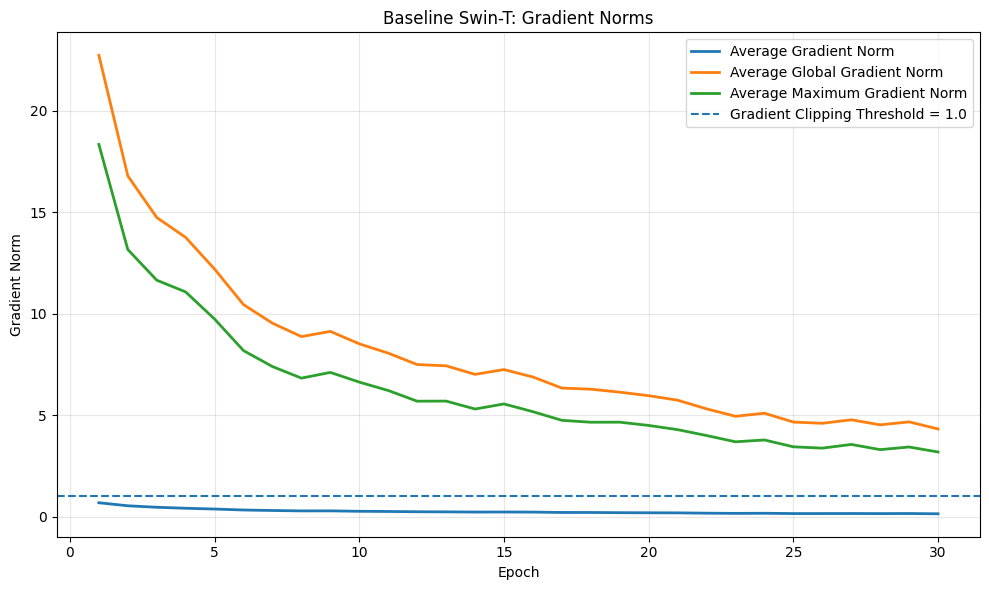

✓ Saved: ./outputs/baseline_swin_t\plots\baseline_gradient_norms.png


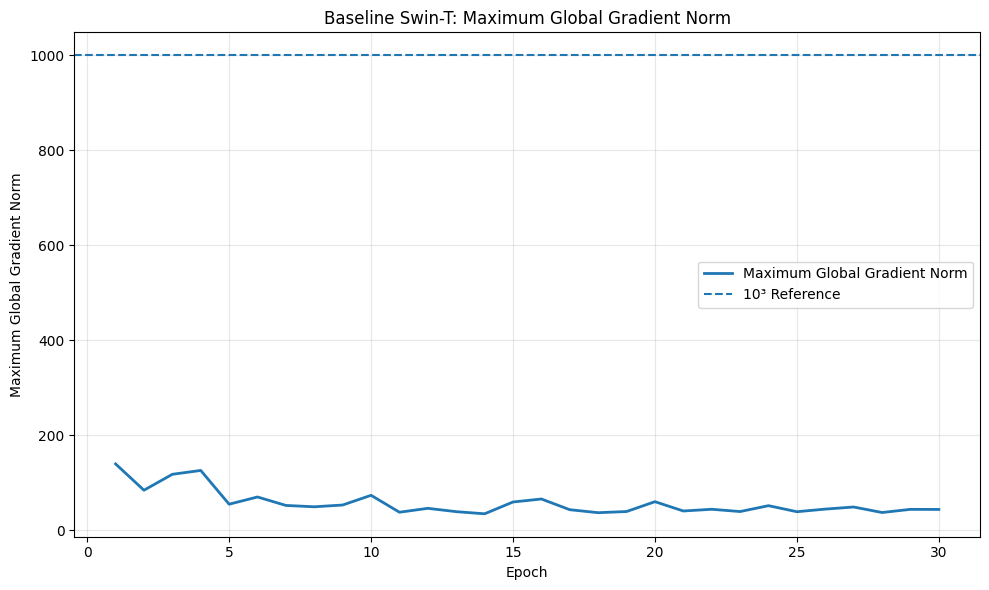

✓ Saved: ./outputs/baseline_swin_t\plots\baseline_max_global_gradient.png


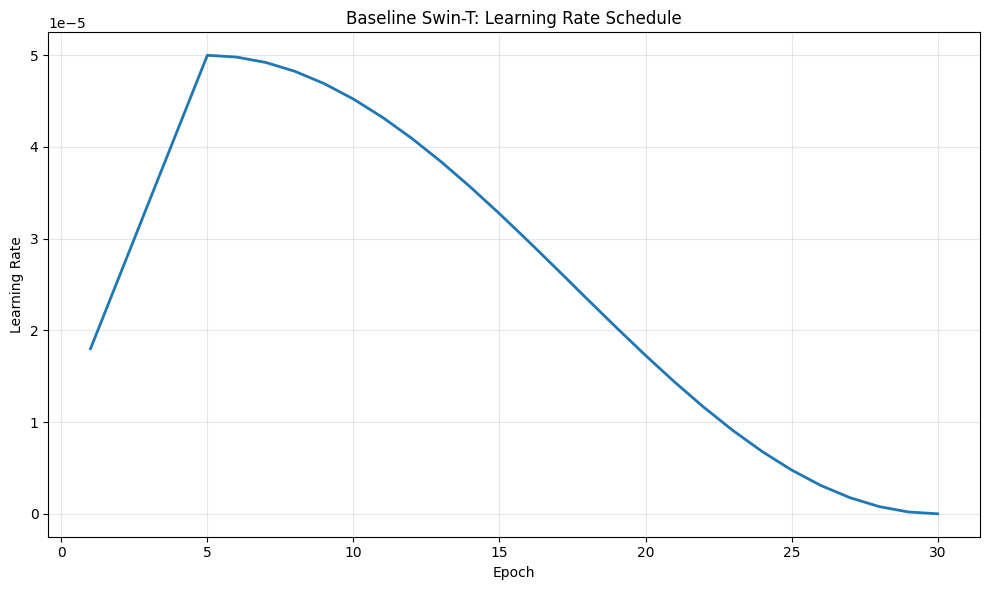

✓ Saved: ./outputs/baseline_swin_t\plots\baseline_learning_rate.png

✓ Saved: ./outputs/baseline_swin_t\baseline_summary.csv

BASELINE PLOTS COMPLETE

Created files:
  ✓ baseline_accuracy_curve.png
  ✓ baseline_gradient_norms.png
  ✓ baseline_learning_rate.png
  ✓ baseline_loss_curve.png
  ✓ baseline_max_global_gradient.png

Baseline result:
  Best epoch:              26
  Best validation accuracy: 99.00%
  Best validation loss:     0.0505
  Maximum global gradient:  139.9587


In [13]:
# ============================================================
# CORRECTED BASELINE PLOTS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
BASELINE_DIR = "./outputs/baseline_swin_t"
HISTORY_PATH = os.path.join(BASELINE_DIR, "history.csv")
PLOTS_DIR = os.path.join(BASELINE_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Load history
# ------------------------------------------------------------
history = pd.read_csv(HISTORY_PATH)

print("=" * 70)
print("BASELINE HISTORY LOADED")
print("=" * 70)

print(f"Number of epochs: {len(history)}")
print(f"History file: {HISTORY_PATH}")

# ------------------------------------------------------------
# 3. Best epoch
# ------------------------------------------------------------
best_idx = history["val_accuracy"].idxmax()

best_epoch = int(history.loc[best_idx, "epoch"])
best_val_acc = float(history.loc[best_idx, "val_accuracy"])
best_val_loss = float(history.loc[best_idx, "val_loss"])

print("\nBASELINE SUMMARY")
print("-" * 70)
print(f"Best Epoch:              {best_epoch}")
print(f"Best Validation Acc:     {best_val_acc:.2f}%")
print(f"Best Validation Loss:    {best_val_loss:.4f}")

# ------------------------------------------------------------
# 4. Plot 1 — Training vs Validation Loss
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Swin-T: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = os.path.join(
    PLOTS_DIR,
    "baseline_loss_curve.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Saved: {loss_path}")


# ------------------------------------------------------------
# 5. Plot 2 — Training vs Validation Accuracy
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["train_accuracy"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["epoch"],
    history["val_accuracy"],
    label="Validation Top-1 Accuracy",
    linewidth=2
)

plt.scatter(
    [best_epoch],
    [best_val_acc],
    s=80,
    zorder=5,
    label=f"Best: {best_val_acc:.2f}%"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Baseline Swin-T: Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_path = os.path.join(
    PLOTS_DIR,
    "baseline_accuracy_curve.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Saved: {accuracy_path}")


# ------------------------------------------------------------
# 6. Plot 3 — Gradient Norms
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["avg_grad_norm"],
    label="Average Gradient Norm",
    linewidth=2
)

plt.plot(
    history["epoch"],
    history["avg_global_grad_norm"],
    label="Average Global Gradient Norm",
    linewidth=2
)

plt.plot(
    history["epoch"],
    history["avg_max_grad_norm"],
    label="Average Maximum Gradient Norm",
    linewidth=2
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    label="Gradient Clipping Threshold = 1.0"
)

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Baseline Swin-T: Gradient Norms")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

gradient_path = os.path.join(
    PLOTS_DIR,
    "baseline_gradient_norms.png"
)

plt.savefig(
    gradient_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Saved: {gradient_path}")


# ------------------------------------------------------------
# 7. Plot 4 — Maximum Global Gradient Norm
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["max_global_grad_norm"],
    linewidth=2,
    label="Maximum Global Gradient Norm"
)

plt.axhline(
    1000,
    linestyle="--",
    linewidth=1.5,
    label="10³ Reference"
)

plt.xlabel("Epoch")
plt.ylabel("Maximum Global Gradient Norm")
plt.title("Baseline Swin-T: Maximum Global Gradient Norm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

max_gradient_path = os.path.join(
    PLOTS_DIR,
    "baseline_max_global_gradient.png"
)

plt.savefig(
    max_gradient_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Saved: {max_gradient_path}")


# ------------------------------------------------------------
# 8. Plot 5 — Learning Rate
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["learning_rate"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Baseline Swin-T: Learning Rate Schedule")
plt.grid(True, alpha=0.3)
plt.tight_layout()

lr_path = os.path.join(
    PLOTS_DIR,
    "baseline_learning_rate.png"
)

plt.savefig(
    lr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Saved: {lr_path}")


# ------------------------------------------------------------
# 9. Save summary
# ------------------------------------------------------------
summary = pd.DataFrame([{
    "best_epoch": best_epoch,
    "best_validation_accuracy": best_val_acc,
    "best_validation_loss": best_val_loss,

    "final_train_accuracy":
        history.iloc[-1]["train_accuracy"],

    "final_validation_accuracy":
        history.iloc[-1]["val_accuracy"],

    "final_train_loss":
        history.iloc[-1]["train_loss"],

    "final_validation_loss":
        history.iloc[-1]["val_loss"],

    "maximum_avg_grad_norm":
        history["avg_grad_norm"].max(),

    "maximum_avg_global_grad_norm":
        history["avg_global_grad_norm"].max(),

    "maximum_global_grad_norm":
        history["max_global_grad_norm"].max()
}])

summary_path = os.path.join(
    BASELINE_DIR,
    "baseline_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print(f"\n✓ Saved: {summary_path}")


# ------------------------------------------------------------
# 10. Final check
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BASELINE PLOTS COMPLETE")
print("=" * 70)

print("\nCreated files:")

for file in sorted(os.listdir(PLOTS_DIR)):
    print("  ✓", file)

print("\nBaseline result:")
print(f"  Best epoch:              {best_epoch}")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")
print(f"  Best validation loss:     {best_val_loss:.4f}")
print(
    f"  Maximum global gradient:  "
    f"{history['max_global_grad_norm'].max():.4f}"
)

In [14]:
# ============================================================
# STEP 1: INSPECT SWIN-T ARCHITECTURE
# ============================================================

import timm
import torch

print("=" * 70)
print("SWIN-T ARCHITECTURE CHECK")
print("=" * 70)

print("timm version:", timm.__version__)
print("PyTorch version:", torch.__version__)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)

print("\nModel created successfully.")
print("Model type:", type(model).__name__)

# ------------------------------------------------------------
# Print the important Swin components
# ------------------------------------------------------------
print("\nSwin stages:")

for i, stage in enumerate(model.layers):
    print(f"\nStage {i + 1}")
    print("  Type:", type(stage).__name__)
    print("  Number of blocks:", len(stage.blocks))

    for j, block in enumerate(stage.blocks[:1]):
        print(f"  Block {j + 1}:")
        print("    Attention:", type(block.attn).__name__)
        print("    MLP:", type(block.mlp).__name__)

        # Window size
        if hasattr(block.attn, "window_size"):
            print("    Window size:", block.attn.window_size)

        # Activation
        if hasattr(block.mlp, "act"):
            print("    Activation:", type(block.mlp.act).__name__)

print("\n" + "=" * 70)
print("ARCHITECTURE INSPECTION COMPLETE")
print("=" * 70)

SWIN-T ARCHITECTURE CHECK
timm version: 1.0.29
PyTorch version: 2.14.0+cu132

Model created successfully.
Model type: SwinTransformer

Swin stages:

Stage 1
  Type: SwinTransformerStage
  Number of blocks: 2
  Block 1:
    Attention: WindowAttention
    MLP: Mlp
    Window size: (7, 7)
    Activation: GELU

Stage 2
  Type: SwinTransformerStage
  Number of blocks: 2
  Block 1:
    Attention: WindowAttention
    MLP: Mlp
    Window size: (7, 7)
    Activation: GELU

Stage 3
  Type: SwinTransformerStage
  Number of blocks: 6
  Block 1:
    Attention: WindowAttention
    MLP: Mlp
    Window size: (7, 7)
    Activation: GELU

Stage 4
  Type: SwinTransformerStage
  Number of blocks: 2
  Block 1:
    Attention: WindowAttention
    MLP: Mlp
    Window size: (7, 7)
    Activation: GELU

ARCHITECTURE INSPECTION COMPLETE


In [1]:
import inspect
import timm
import torch.nn as nn

from timm.models.swin_transformer import SwinTransformer

print("timm version:", timm.__version__)
print()
print("SwinTransformer constructor:")
print(inspect.signature(SwinTransformer))

timm version: 1.0.29

SwinTransformer constructor:
(img_size: Union[int, Tuple[int, int]] = 224, patch_size: int = 4, in_chans: int = 3, num_classes: int = 1000, global_pool: str = 'avg', embed_dim: int = 96, depths: Tuple[int, ...] = (2, 2, 6, 2), num_heads: Tuple[int, ...] = (3, 6, 12, 24), head_dim: Optional[int] = None, window_size: Union[int, Tuple[int, int]] = 7, always_partition: bool = False, strict_img_size: bool = True, mlp_ratio: float = 4.0, qkv_bias: bool = True, drop_rate: float = 0.0, proj_drop_rate: float = 0.0, attn_drop_rate: float = 0.0, drop_path_rate: float = 0.1, embed_layer: Type[torch.nn.modules.module.Module] = <class 'timm.layers.patch_embed.PatchEmbed'>, norm_layer: Union[str, Type[torch.nn.modules.module.Module]] = <class 'torch.nn.modules.normalization.LayerNorm'>, weight_init: str = '', device=None, dtype=None, **kwargs)


In [2]:
import torch
import torch.nn as nn
import timm

from timm.models.swin_transformer import SwinTransformer

# ============================================================
# MODIFIED SWIN-T
# Changes:
#   1. Window size: 7x7 -> 5x5
#   2. Activation: GELU -> SiLU
# ============================================================

NUM_CLASSES = 10

modified_model = SwinTransformer(
    img_size=224,
    patch_size=4,
    in_chans=3,
    num_classes=NUM_CLASSES,
    global_pool='avg',
    embed_dim=96,
    depths=(2, 2, 6, 2),
    num_heads=(3, 6, 12, 24),
    window_size=5,
    mlp_ratio=4.0,
    qkv_bias=True,
    drop_rate=0.0,
    proj_drop_rate=0.0,
    attn_drop_rate=0.0,
    drop_path_rate=0.1,
)

# ------------------------------------------------------------
# Change GELU -> SiLU in every MLP block
# ------------------------------------------------------------

silu_count = 0

for module in modified_model.modules():
    if hasattr(module, "act") and isinstance(module.act, nn.GELU):
        module.act = nn.SiLU()
        silu_count += 1

print("=" * 60)
print("MODIFIED SWIN-T CREATED")
print("=" * 60)

print("Model type:", type(modified_model).__name__)
print("Window size: 5x5")
print("Activation: SiLU")
print("Number of SiLU activations:", silu_count)
print("Number of classes:", NUM_CLASSES)

print("=" * 60)

MODIFIED SWIN-T CREATED
Model type: SwinTransformer
Window size: 5x5
Activation: SiLU
Number of SiLU activations: 12
Number of classes: 10


In [3]:
# Check window sizes and activation functions

print("\nChecking Swin blocks...")

for name, module in modified_model.named_modules():
    if hasattr(module, "window_size") and hasattr(module, "mlp"):
        print(
            name,
            "| Window:", module.window_size,
            "| Activation:", module.mlp.act.__class__.__name__
        )


Checking Swin blocks...
layers.0.blocks.0 | Window: (5, 5) | Activation: SiLU
layers.0.blocks.1 | Window: (5, 5) | Activation: SiLU
layers.1.blocks.0 | Window: (5, 5) | Activation: SiLU
layers.1.blocks.1 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.0 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.1 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.2 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.3 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.4 | Window: (5, 5) | Activation: SiLU
layers.2.blocks.5 | Window: (5, 5) | Activation: SiLU
layers.3.blocks.0 | Window: (5, 5) | Activation: SiLU
layers.3.blocks.1 | Window: (5, 5) | Activation: SiLU


In [5]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ============================================================
# RECREATE DATA LOADERS USING THE SAVED SPLIT
# ============================================================

DATA_DIR = "./data"
SPLIT_DIR = "./splits"

BATCH_SIZE = 32
NUM_WORKERS = 0

# Same normalization required by the assignment
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Training transform
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation transform
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load EuroSAT twice so train/validation can have different transforms
train_dataset_full = datasets.EuroSAT(
    root=DATA_DIR,
    download=False,
    transform=train_transform
)

val_dataset_full = datasets.EuroSAT(
    root=DATA_DIR,
    download=False,
    transform=val_transform
)

# Load the SAME fixed split used for the baseline
train_indices = np.load(
    os.path.join(SPLIT_DIR, "train_indices.npy")
)

val_indices = np.load(
    os.path.join(SPLIT_DIR, "val_indices.npy")
)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("DATA LOADERS READY")
print("=" * 60)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

DATA LOADERS READY
Training images: 21600
Validation images: 5400
Batch size: 32
Training batches: 675
Validation batches: 169


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

modified_model = modified_model.to(device)
modified_model.train()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)

outputs = modified_model(images)

print("Output shape:", outputs.shape)

criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)

print("Loss:", loss.item())

modified_model.zero_grad(set_to_none=True)
loss.backward()

print("Backward pass: SUCCESS")

print("=" * 60)
print("MODIFIED MODEL SANITY TEST PASSED")
print("=" * 60)

Using device: cuda
Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 10])
Loss: 2.432497024536133
Backward pass: SUCCESS
MODIFIED MODEL SANITY TEST PASSED


In [7]:
# ============================================================
# LOAD ORIGINAL PRETRAINED SWIN-T
# This model is only used as the source of pretrained weights.
# ============================================================

import timm
import torch

print("Loading original pretrained Swin-T...")

pretrained_model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)

print("Pretrained Swin-T loaded successfully.")
print("Source model:", type(pretrained_model).__name__)

Loading original pretrained Swin-T...
Pretrained Swin-T loaded successfully.
Source model: SwinTransformer


In [8]:
# ============================================================
# TRANSFER PRETRAINED WEIGHTS
# 7x7 Swin-T -> 5x5 Swin-T
#
# Relative-position bias tables are resized from:
#       13 x 13  ->  9 x 9
# because:
#       2*7 - 1 = 13
#       2*5 - 1 = 9
# ============================================================

import torch
import torch.nn.functional as F

source_state = pretrained_model.state_dict()
target_state = modified_model.state_dict()

new_state = {}

transferred = 0
resized = 0
skipped = []

for key, target_tensor in target_state.items():

    if key not in source_state:
        skipped.append(key)
        continue

    source_tensor = source_state[key]

    # --------------------------------------------------------
    # Relative position bias table:
    # pretrained: [169, num_heads]  -> 13x13
    # modified:   [81, num_heads]   ->  9x9
    # --------------------------------------------------------
    if "relative_position_bias_table" in key:

        num_heads = target_tensor.shape[1]

        source_h = int(source_tensor.shape[0] ** 0.5)
        target_h = int(target_tensor.shape[0] ** 0.5)

        if (
            source_h * source_h == source_tensor.shape[0]
            and target_h * target_h == target_tensor.shape[0]
        ):
            # [169, heads] -> [heads, 13, 13]
            bias = source_tensor.transpose(0, 1).reshape(
                1, num_heads, source_h, source_h
            )

            # Resize 13x13 -> 9x9
            bias = F.interpolate(
                bias,
                size=(target_h, target_h),
                mode="bicubic",
                align_corners=False
            )

            # [1, heads, 9, 9] -> [81, heads]
            bias = bias.reshape(
                num_heads, target_h * target_h
            ).transpose(0, 1)

            new_state[key] = bias
            resized += 1
            continue

    # --------------------------------------------------------
    # Normal parameters with matching shape
    # --------------------------------------------------------
    if source_tensor.shape == target_tensor.shape:
        new_state[key] = source_tensor
        transferred += 1
    else:
        skipped.append(
            f"{key} | source {tuple(source_tensor.shape)} "
            f"-> target {tuple(target_tensor.shape)}"
        )

# Load transferred weights
missing, unexpected = modified_model.load_state_dict(
    new_state,
    strict=False
)

print("=" * 65)
print("PRETRAINED WEIGHT TRANSFER COMPLETE")
print("=" * 65)

print("Normal parameters transferred:", transferred)
print("Relative-position tables resized:", resized)
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
print("Skipped/mismatched parameters:", len(skipped))

if skipped:
    print("\nFirst few skipped/mismatched parameters:")
    for item in skipped[:10]:
        print(" -", item)

print("=" * 65)

PRETRAINED WEIGHT TRANSFER COMPLETE
Normal parameters transferred: 161
Relative-position tables resized: 12
Missing keys: 0
Unexpected keys: 0
Skipped/mismatched parameters: 0


In [9]:
# ============================================================
# FINAL PRE-TRAINING SANITY CHECK
# ============================================================

modified_model.eval()

with torch.no_grad():
    test_images, test_labels = next(iter(val_loader))

    test_images = test_images.to(device)
    test_labels = test_labels.to(device)

    test_outputs = modified_model(test_images)

print("=" * 60)
print("FINAL MODEL CHECK")
print("=" * 60)

print("Input shape :", test_images.shape)
print("Output shape:", test_outputs.shape)
print("Output contains NaN:", torch.isnan(test_outputs).any().item())
print("Output contains Inf:", torch.isinf(test_outputs).any().item())

print("=" * 60)
print("READY FOR TRAINING")
print("=" * 60)

FINAL MODEL CHECK
Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])
Output contains NaN: False
Output contains Inf: False
READY FOR TRAINING


In [10]:
# ============================================================
# ABLATION EXPERIMENT
# Swin-T: 7x7 GELU -> 5x5 SiLU
# ============================================================

import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 2. EXPERIMENT SETTINGS
# ============================================================

EXPERIMENT_NAME = "ablation_window5_silu"

OUTPUT_DIR = os.path.join(
    "./outputs",
    EXPERIMENT_NAME
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES = 10
EPOCHS = 30
BATCH_SIZE = 32

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0

# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("STARTING ABLATION EXPERIMENT")
print("=" * 70)

print("Experiment:", EXPERIMENT_NAME)
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup epochs:", WARMUP_EPOCHS)
print("Gradient clipping:", GRAD_CLIP)
print("Architecture: Swin-T + 5x5 windows + SiLU")
print("=" * 70)

# ============================================================
# 4. MOVE MODEL TO GPU
# ============================================================

modified_model = modified_model.to(device)

# ============================================================
# 5. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    modified_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ============================================================
# 6. LEARNING-RATE SCHEDULE
# 5-EPOCH LINEAR WARMUP + COSINE DECAY
# ============================================================

def get_learning_rate(epoch):

    # epoch is 1-based

    if epoch <= WARMUP_EPOCHS:

        # Start at 20% of LR and linearly increase
        warmup_start = LEARNING_RATE * 0.2

        progress = (
            (epoch - 1)
            / max(1, WARMUP_EPOCHS - 1)
        )

        return (
            warmup_start
            + progress * (LEARNING_RATE - warmup_start)
        )

    else:

        progress = (
            (epoch - WARMUP_EPOCHS)
            / max(1, EPOCHS - WARMUP_EPOCHS)
        )

        return (
            LEARNING_RATE
            * 0.5
            * (1 + np.cos(np.pi * progress))
        )


def set_learning_rate(optimizer, lr):

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr


# ============================================================
# 7. GRADIENT STATISTICS
# ============================================================

def calculate_gradient_statistics(model):

    grad_norms = []

    for parameter in model.parameters():

        if parameter.grad is not None:

            grad_norms.append(
                parameter.grad.detach().norm(2).item()
            )

    if len(grad_norms) == 0:

        return 0.0, 0.0, 0.0

    avg_grad_norm = float(np.mean(grad_norms))
    max_grad_norm = float(np.max(grad_norms))

    global_grad_norm = float(
        np.sqrt(
            sum(x ** 2 for x in grad_norms)
        )
    )

    return (
        avg_grad_norm,
        global_grad_norm,
        max_grad_norm
    )


# ============================================================
# 8. TRAINING HISTORY
# ============================================================

history = []

best_val_accuracy = -1.0
best_epoch = -1

# ============================================================
# 9. TRAINING LOOP
# ============================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # --------------------------------------------------------
    # Learning rate
    # --------------------------------------------------------

    current_lr = get_learning_rate(epoch)

    set_learning_rate(
        optimizer,
        current_lr
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    modified_model.train()

    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    epoch_avg_gradients = []
    epoch_global_gradients = []
    epoch_max_gradients = []
    epoch_max_global_gradient = 0.0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward
        outputs = modified_model(images)

        loss = criterion(
            outputs,
            labels
        )

        # Backward
        loss.backward()

        # Gradient statistics BEFORE clipping
        (
            avg_grad,
            global_grad,
            max_grad
        ) = calculate_gradient_statistics(
            modified_model
        )

        epoch_avg_gradients.append(
            avg_grad
        )

        epoch_global_gradients.append(
            global_grad
        )

        epoch_max_gradients.append(
            max_grad
        )

        epoch_max_global_gradient = max(
            epoch_max_global_gradient,
            global_grad
        )

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            modified_model.parameters(),
            GRAD_CLIP
        )

        # Optimizer
        optimizer.step()

        # Statistics
        train_loss_total += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        train_loss_total
        / train_total
    )

    train_accuracy = (
        100.0
        * train_correct
        / train_total
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    modified_model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = modified_model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss_total += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        val_loss_total
        / val_total
    )

    val_accuracy = (
        100.0
        * val_correct
        / val_total
    )

    # --------------------------------------------------------
    # GRADIENT SUMMARY
    # --------------------------------------------------------

    avg_grad_norm = float(
        np.mean(epoch_avg_gradients)
    )

    avg_global_grad_norm = float(
        np.mean(epoch_global_gradients)
    )

    avg_max_grad_norm = float(
        np.mean(epoch_max_gradients)
    )

    # --------------------------------------------------------
    # TIME
    # --------------------------------------------------------

    epoch_time = (
        time.time()
        - epoch_start
    )

    # --------------------------------------------------------
    # SAVE HISTORY ROW
    # --------------------------------------------------------

    row = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "avg_grad_norm": avg_grad_norm,
        "avg_global_grad_norm": avg_global_grad_norm,
        "avg_max_grad_norm": avg_max_grad_norm,
        "max_global_grad_norm": epoch_max_global_gradient,
        "epoch_time_seconds": epoch_time
    }

    history.append(row)

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "history.csv"
        ),
        index=False
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch

        torch.save(
            modified_model.state_dict(),
            os.path.join(
                OUTPUT_DIR,
                "best_model.pth"
            )
        )

        best_marker = " <-- BEST"

    else:

        best_marker = ""

    # --------------------------------------------------------
    # SAVE LATEST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": modified_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_accuracy": best_val_accuracy,
            "best_epoch": best_epoch,
            "history": history
        },
        os.path.join(
            OUTPUT_DIR,
            "latest_checkpoint.pth"
        )
    )

    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"\nEpoch {epoch:02d}/{EPOCHS} "
        f"| LR={current_lr:.8f}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc: {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Val Acc: {val_accuracy:.2f}%"
        f"{best_marker}"
    )

    print(
        f"Avg Grad Norm: {avg_grad_norm:.4f}"
    )

    print(
        f"Global Grad Norm: {avg_global_grad_norm:.4f}"
    )

    print(
        f"Max Grad Norm: {avg_max_grad_norm:.4f}"
    )

    print(
        f"Epoch Time: {epoch_time / 60:.2f} min"
    )


# ============================================================
# 10. SAVE CONFIGURATION
# ============================================================

config = {
    "experiment_name": EXPERIMENT_NAME,
    "architecture": "Swin-T",
    "window_size": 5,
    "activation": "SiLU",
    "num_classes": NUM_CLASSES,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS,
    "gradient_clipping": GRAD_CLIP,
    "image_size": 224,
    "optimizer": "AdamW",
    "split_seed": 42,
    "model_seed": SEED,
    "train_images": len(train_dataset),
    "validation_images": len(val_dataset)
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "config.json"
    ),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("ABLATION TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best Epoch: {best_epoch}"
)

print(
    "History:",
    os.path.join(
        OUTPUT_DIR,
        "history.csv"
    )
)

print(
    "Best Model:",
    os.path.join(
        OUTPUT_DIR,
        "best_model.pth"
    )
)

print("=" * 70)

STARTING ABLATION EXPERIMENT
Experiment: ablation_window5_silu
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Batch size: 32
Epochs: 30
Learning rate: 5e-05
Weight decay: 0.0001
Warmup epochs: 5
Gradient clipping: 1.0
Architecture: Swin-T + 5x5 windows + SiLU

Epoch 01/30 | LR=0.00001000
Train Loss: 0.7314
Train Acc: 75.56%
Val Loss: 0.2563
Val Acc: 91.17% <-- BEST
Avg Grad Norm: 0.8375
Global Grad Norm: 22.1527
Max Grad Norm: 14.4549
Epoch Time: 6.69 min

Epoch 02/30 | LR=0.00002000
Train Loss: 0.3522
Train Acc: 88.51%
Val Loss: 0.1803
Val Acc: 93.69% <-- BEST
Avg Grad Norm: 0.7563
Global Grad Norm: 21.7514
Max Grad Norm: 15.8862
Epoch Time: 5.32 min

Epoch 03/30 | LR=0.00003000
Train Loss: 0.2757
Train Acc: 90.84%
Val Loss: 0.1449
Val Acc: 95.06% <-- BEST
Avg Grad Norm: 0.6207
Global Grad Norm: 19.3431
Max Grad Norm: 14.9776
Epoch Time: 5.38 min

Epoch 04/30 | LR=0.00004000
Train Loss: 0.2459
Train Acc: 92.13%
Val Loss: 0.1273
Val Acc: 95.83% <-- BEST
Avg Grad Norm: 0.4917
G

Baseline rows: 30
Ablation rows: 30

Baseline columns:
['epoch', 'learning_rate', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'avg_grad_norm', 'avg_global_grad_norm', 'avg_max_grad_norm', 'max_global_grad_norm', 'epoch_time_seconds']

Ablation columns:
['epoch', 'learning_rate', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'avg_grad_norm', 'avg_global_grad_norm', 'avg_max_grad_norm', 'max_global_grad_norm', 'epoch_time_seconds']


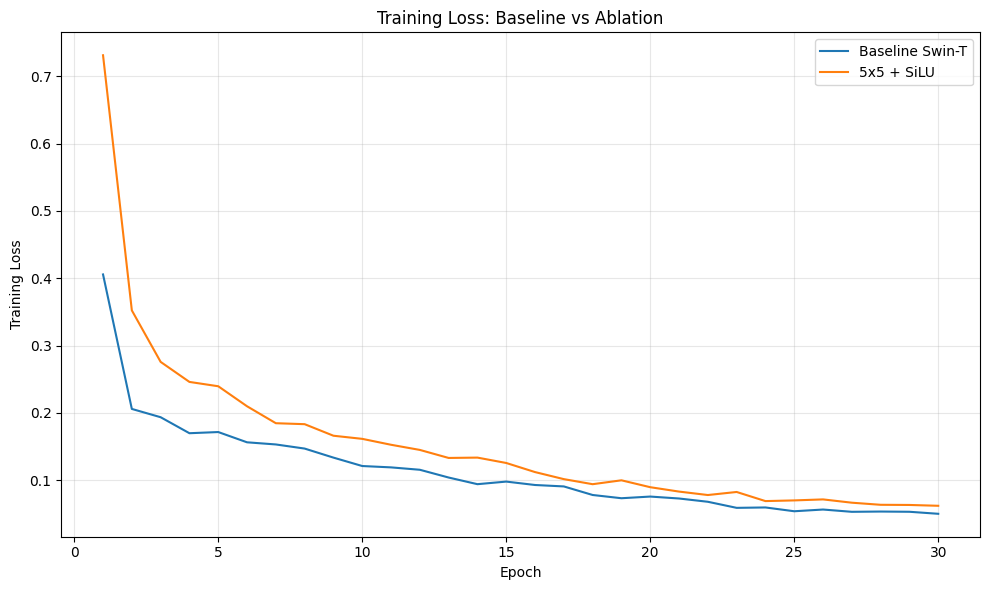

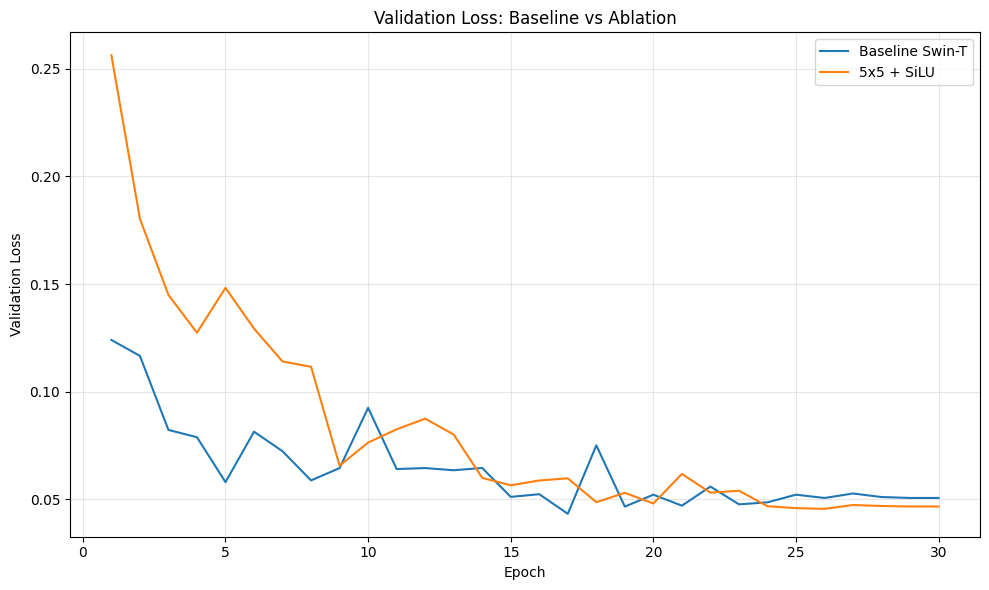

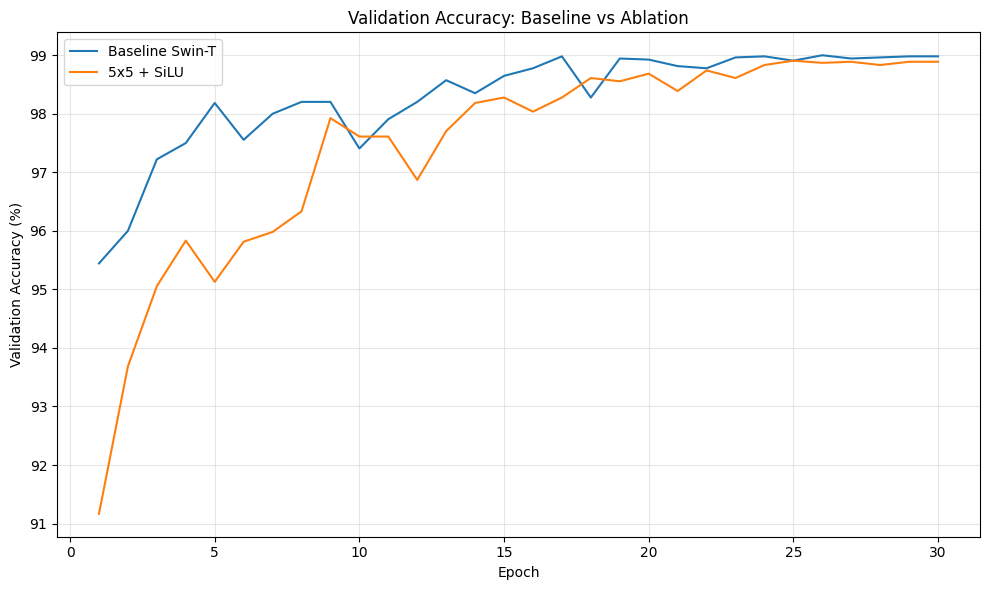

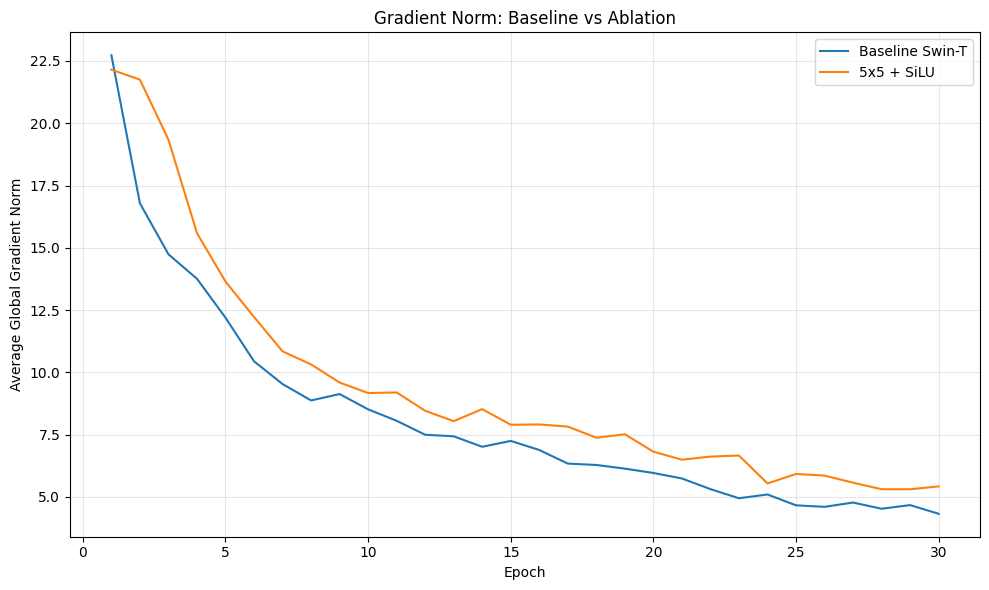

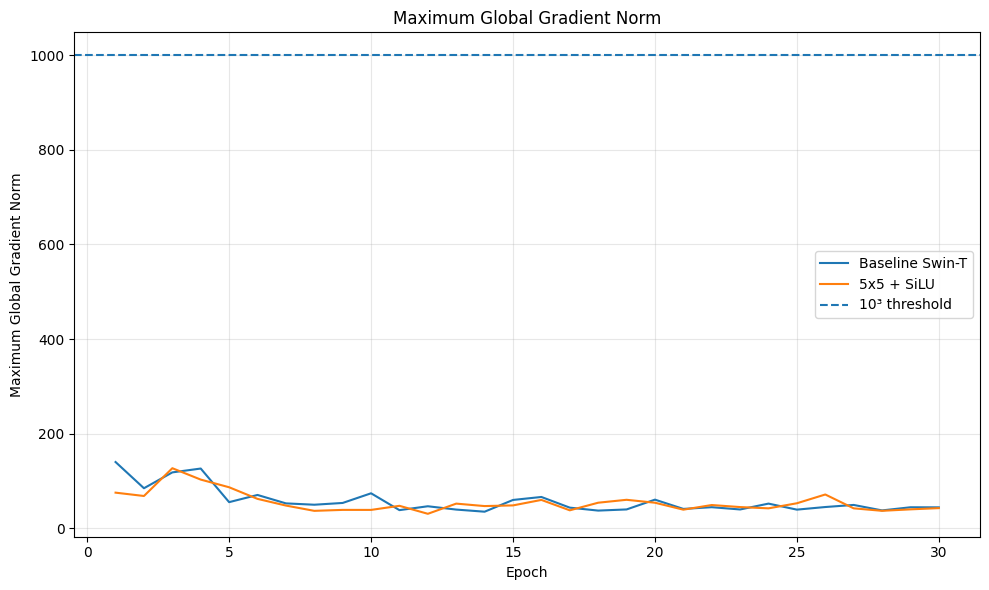



BASELINE vs ABLATION SUMMARY


,Model,Best Val Accuracy (%),Best Epoch,Best Val Loss,Final Val Accuracy (%),Maximum Global Gradient
0,Baseline Swin-T,99.000000,26,0.043181,98.981481,139.958694
1,Swin-T 5x5 + SiLU,98.907407,25,0.045486,98.888889,126.895470



Saved comparison files to:
./outputs/comparison_plots


In [11]:
# ============================================================
# BASELINE vs ABLATION COMPARISON PLOTS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASELINE_DIR = "./outputs/baseline_swin_t"
ABLATION_DIR = "./outputs/ablation_window5_silu"

PLOT_DIR = "./outputs/comparison_plots"

os.makedirs(PLOT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load histories
# ------------------------------------------------------------

baseline = pd.read_csv(
    os.path.join(BASELINE_DIR, "history.csv")
)

ablation = pd.read_csv(
    os.path.join(ABLATION_DIR, "history.csv")
)

print("Baseline rows:", len(baseline))
print("Ablation rows:", len(ablation))

print("\nBaseline columns:")
print(baseline.columns.tolist())

print("\nAblation columns:")
print(ablation.columns.tolist())


# ============================================================
# 1. OVERLAID TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline["epoch"],
    baseline["train_loss"],
    label="Baseline Swin-T"
)

plt.plot(
    ablation["epoch"],
    ablation["train_loss"],
    label="5x5 + SiLU"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Baseline vs Ablation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_train_loss.png"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_train_loss.svg"
    )
)

plt.show()


# ============================================================
# 2. OVERLAID VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline["epoch"],
    baseline["val_loss"],
    label="Baseline Swin-T"
)

plt.plot(
    ablation["epoch"],
    ablation["val_loss"],
    label="5x5 + SiLU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs Ablation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_val_loss.png"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_val_loss.svg"
    )
)

plt.show()


# ============================================================
# 3. OVERLAID VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline["epoch"],
    baseline["val_accuracy"],
    label="Baseline Swin-T"
)

plt.plot(
    ablation["epoch"],
    ablation["val_accuracy"],
    label="5x5 + SiLU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy: Baseline vs Ablation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_val_accuracy.png"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_val_accuracy.svg"
    )
)

plt.show()


# ============================================================
# 4. OVERLAID AVERAGE GLOBAL GRADIENT NORM
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline["epoch"],
    baseline["avg_global_grad_norm"],
    label="Baseline Swin-T"
)

plt.plot(
    ablation["epoch"],
    ablation["avg_global_grad_norm"],
    label="5x5 + SiLU"
)

plt.xlabel("Epoch")
plt.ylabel("Average Global Gradient Norm")
plt.title("Gradient Norm: Baseline vs Ablation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_gradient_norm.png"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_gradient_norm.svg"
    )
)

plt.show()


# ============================================================
# 5. MAXIMUM GLOBAL GRADIENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline["epoch"],
    baseline["max_global_grad_norm"],
    label="Baseline Swin-T"
)

plt.plot(
    ablation["epoch"],
    ablation["max_global_grad_norm"],
    label="5x5 + SiLU"
)

plt.axhline(
    y=1000,
    linestyle="--",
    label="10³ threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Maximum Global Gradient Norm")
plt.title("Maximum Global Gradient Norm")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_max_gradient.png"
    ),
    dpi=300
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "comparison_max_gradient.svg"
    )
)

plt.show()


# ============================================================
# 6. CREATE NUMERICAL SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Model": [
        "Baseline Swin-T",
        "Swin-T 5x5 + SiLU"
    ],

    "Best Val Accuracy (%)": [
        baseline["val_accuracy"].max(),
        ablation["val_accuracy"].max()
    ],

    "Best Epoch": [
        baseline.loc[
            baseline["val_accuracy"].idxmax(),
            "epoch"
        ],
        ablation.loc[
            ablation["val_accuracy"].idxmax(),
            "epoch"
        ]
    ],

    "Best Val Loss": [
        baseline["val_loss"].min(),
        ablation["val_loss"].min()
    ],

    "Final Val Accuracy (%)": [
        baseline.iloc[-1]["val_accuracy"],
        ablation.iloc[-1]["val_accuracy"]
    ],

    "Maximum Global Gradient": [
        baseline["max_global_grad_norm"].max(),
        ablation["max_global_grad_norm"].max()
    ]
})

print("\n")
print("=" * 80)
print("BASELINE vs ABLATION SUMMARY")
print("=" * 80)

display(summary)

summary.to_csv(
    os.path.join(
        PLOT_DIR,
        "baseline_vs_ablation_summary.csv"
    ),
    index=False
)

print("\nSaved comparison files to:")
print(PLOT_DIR)